            amount         hour  distance_from_home  transactions_today
count  1000.000000  1000.000000         1000.000000         1000.000000
mean    389.002379    11.303000            9.933617            7.374000
std     389.003954     6.838125            9.782952            3.967097
min       1.857114     0.000000            0.001347            1.000000
25%     107.662612     5.000000            3.001938            4.000000
50%     274.713047    11.000000            6.963445            7.000000
75%     545.532083    17.000000           14.006429           11.000000
max    3268.978239    23.000000           64.054729           14.000000
flagged
Normal     950
FLAGGED     50
Name: count, dtype: int64
Sample of flagged transactions:


,amount,hour,distance_from_home,transactions_today,anomaly_score,flagged
293,178.634010,0,64.054729,12,-0.103213,FLAGGED
531,3268.978239,0,11.108842,2,-0.097967,FLAGGED
3,365.177022,23,48.482633,4,-0.097332,FLAGGED
475,1982.731443,22,0.827368,14,-0.093001,FLAGGED
868,791.579731,14,61.288230,5,-0.089939,FLAGGED
66,60.759259,17,57.128799,12,-0.087849,FLAGGED
799,1022.987743,3,50.910413,11,-0.087398,FLAGGED
54,364.421765,10,52.719320,3,-0.081419,FLAGGED
251,194.516773,8,56.087462,13,-0.080409,FLAGGED
154,1697.614793,19,34.376550,11,-0.075460,FLAGGED



Average values — Normal vs Flagged:


,amount,hour,distance_from_home,transactions_today
flagged,,,,
FLAGGED,1003.4,12.2,29.0,7.3
Normal,356.7,11.3,8.9,7.4


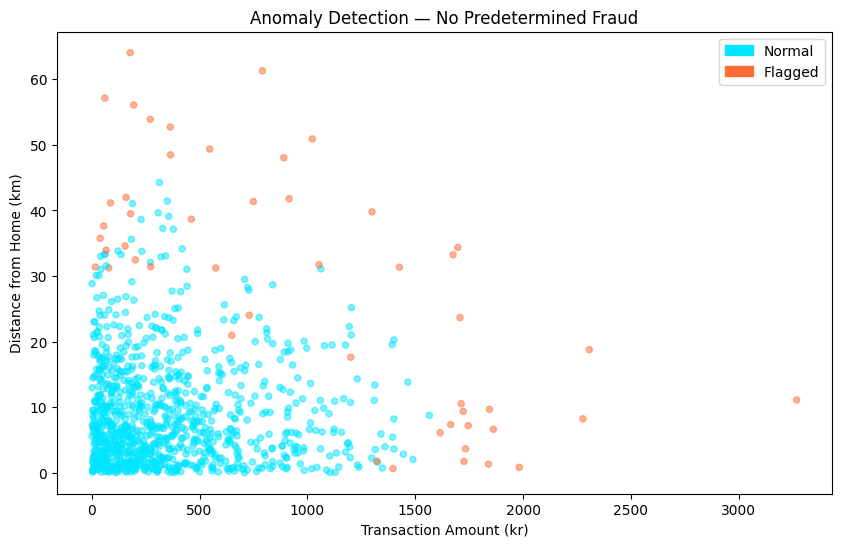

3      CUST_0004
50     CUST_0051
54     CUST_0055
57     CUST_0058
66     CUST_0067
69     CUST_0070
139    CUST_0140
154    CUST_0155
166    CUST_0167
203    CUST_0204
228    CUST_0229
245    CUST_0246
251    CUST_0252
261    CUST_0262
293    CUST_0294
335    CUST_0336
366    CUST_0367
372    CUST_0373
390    CUST_0391
417    CUST_0418
441    CUST_0442
446    CUST_0447
469    CUST_0470
475    CUST_0476
488    CUST_0489
499    CUST_0500
504    CUST_0505
518    CUST_0519
531    CUST_0532
532    CUST_0533
539    CUST_0540
582    CUST_0583
653    CUST_0654
661    CUST_0662
675    CUST_0676
705    CUST_0706
766    CUST_0767
771    CUST_0772
773    CUST_0774
790    CUST_0791
799    CUST_0800
810    CUST_0811
811    CUST_0812
820    CUST_0821
837    CUST_0838
842    CUST_0843
847    CUST_0848
868    CUST_0869
932    CUST_0933
985    CUST_0986
Name: customer_ID, dtype: object


,customer_ID,amount,hour,distance_from_home,transactions_today,anomaly_score
293,CUST_0294,178.634010,0,64.054729,12,-0.103213
531,CUST_0532,3268.978239,0,11.108842,2,-0.097967
3,CUST_0004,365.177022,23,48.482633,4,-0.097332
475,CUST_0476,1982.731443,22,0.827368,14,-0.093001
868,CUST_0869,791.579731,14,61.288230,5,-0.089939
66,CUST_0067,60.759259,17,57.128799,12,-0.087849
799,CUST_0800,1022.987743,3,50.910413,11,-0.087398
54,CUST_0055,364.421765,10,52.719320,3,-0.081419
251,CUST_0252,194.516773,8,56.087462,13,-0.080409
154,CUST_0155,1697.614793,19,34.376550,11,-0.075460


Report saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'amount': np.random.exponential(scale=400, size=n),
    'hour': np.random.randint(0, 24, n),
    'distance_from_home': np.random.exponential(scale=10, size=n),
    'transactions_today': np.random.randint(1, 15, n)
})

print(df.describe())
df.head()

features = ['amount', 'hour', 'distance_from_home', 'transactions_today']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_scaled)

df['anomaly_score'] = model.decision_function(X_scaled)
df['flagged'] = model.predict(X_scaled)
df['flagged'] = df['flagged'].map({1: 'Normal', -1: 'FLAGGED'})

print(df['flagged'].value_counts())

print("Sample of flagged transactions:")
display(df[df['flagged'] == 'FLAGGED'].sort_values('anomaly_score').head(10))

print("\nAverage values — Normal vs Flagged:")
display(df.groupby('flagged')[features].mean().round(1))

plt.figure(figsize=(10, 6))
colors = df['flagged'].map({'Normal': '#00e5ff', 'FLAGGED': '#ff6b35'})

plt.scatter(df['amount'], df['distance_from_home'],
            c=colors, alpha=0.5, s=20)

plt.xlabel('Transaction Amount (kr)')
plt.ylabel('Distance from Home (km)')
plt.title('Anomaly Detection — No Predetermined Fraud')

from matplotlib.patches import Patch
legend = [Patch(color='#00e5ff', label='Normal'),
          Patch(color='#ff6b35', label='Flagged')]
plt.legend(handles=legend)
plt.show()

# Add unique ID to each transaction
df['customer_ID'] = ['CUST_' + str(i).zfill(4) for i in range(1, n+1)]

flagged_customers = df[df['flagged'] == 'FLAGGED']['customer_ID']
print(flagged_customers)

flagged_report = df[df['flagged'] == 'FLAGGED'][[
    'customer_ID',
    'amount',
    'hour',
    'distance_from_home',
    'transactions_today',
    'anomaly_score'
]].sort_values('anomaly_score')  # most suspicious first

display(flagged_report)

flagged_report.to_csv('flagged_transactions.csv', index=False)
print("Report saved.")